# **Predicting Loan Payback**

In [80]:
# librarys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve

#model 

from xgboost import XGBClassifier
import catboost as cb
import lightgbm as lgbm


### 1. Data Load

In [81]:
# Testing Data
x_test = pd.read_csv(r"/kaggle/input/loan-test/test.csv")

In [82]:
dataset = pd.read_csv(r"/kaggle/input/loan-data-train/train.csv")
dataset.head(3)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0


In [83]:
# Dataset shape
dataset.shape

(593994, 13)

In [84]:
# Dataset related informations
dataset.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


### 2. Preprocessing

In [85]:
# fing missing values
dataset.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [86]:
# find duplicate data
dataset.duplicated().sum()

0

### 3. Encoding data

In [87]:
dataset.head(2)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0


In [88]:
dataset.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

In [89]:
# Column unique values find for encodeing

print(f"1. Married status unique  values:\n {dataset['marital_status'].unique()}")
print()
print(f"2. Education level unique values:\n {dataset['education_level'].unique()}")
print()
print(f"3. Employment status unique values:\n {dataset['employment_status'].unique()}")
print()
print(f"4. Loan purpose unique values:\n {dataset['loan_purpose'].unique()}")
print()
print(f"5. Grade_subgrade unique value:\n {dataset['grade_subgrade'].unique()}")
print()
print(f"6. Gender unique value:\n {dataset['gender'].unique()}")

1. Married status unique  values:
 ['Single' 'Married' 'Divorced' 'Widowed']

2. Education level unique values:
 ['High School' "Master's" "Bachelor's" 'PhD' 'Other']

3. Employment status unique values:
 ['Self-employed' 'Employed' 'Unemployed' 'Retired' 'Student']

4. Loan purpose unique values:
 ['Other' 'Debt consolidation' 'Home' 'Education' 'Vacation' 'Car'
 'Medical' 'Business']

5. Grade_subgrade unique value:
 ['C3' 'D3' 'C5' 'F1' 'D1' 'D5' 'C2' 'C1' 'F5' 'D4' 'C4' 'D2' 'E5' 'B1'
 'B2' 'F4' 'A4' 'E1' 'F2' 'B4' 'E4' 'B3' 'E3' 'B5' 'E2' 'F3' 'A5' 'A3'
 'A1' 'A2']

6. Gender unique value:
 ['Female' 'Male' 'Other']


In [90]:
# Label Encoding
label_en = LabelEncoder()
dataset[
    ['gender', 'marital_status','education_level', 'employment_status', 'loan_purpose','grade_subgrade']
] = label_en.fit_transform(['gender', 'marital_status','education_level', 'employment_status', 'loan_purpose','grade_subgrade'])

## Data Visualization

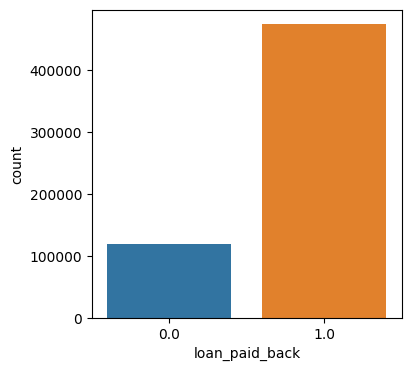

In [91]:
# Count Class data
plt.figure(figsize=(4,4))
sns.countplot(x=dataset['loan_paid_back'] )
plt.show()

### 4. Feature Scaling

In [92]:
dataset.head(3)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,2,5,0,1,4,3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,2,5,0,1,4,3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,2,5,0,1,4,3,1.0


### Outlier Detection and remove

In [93]:
dataset.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

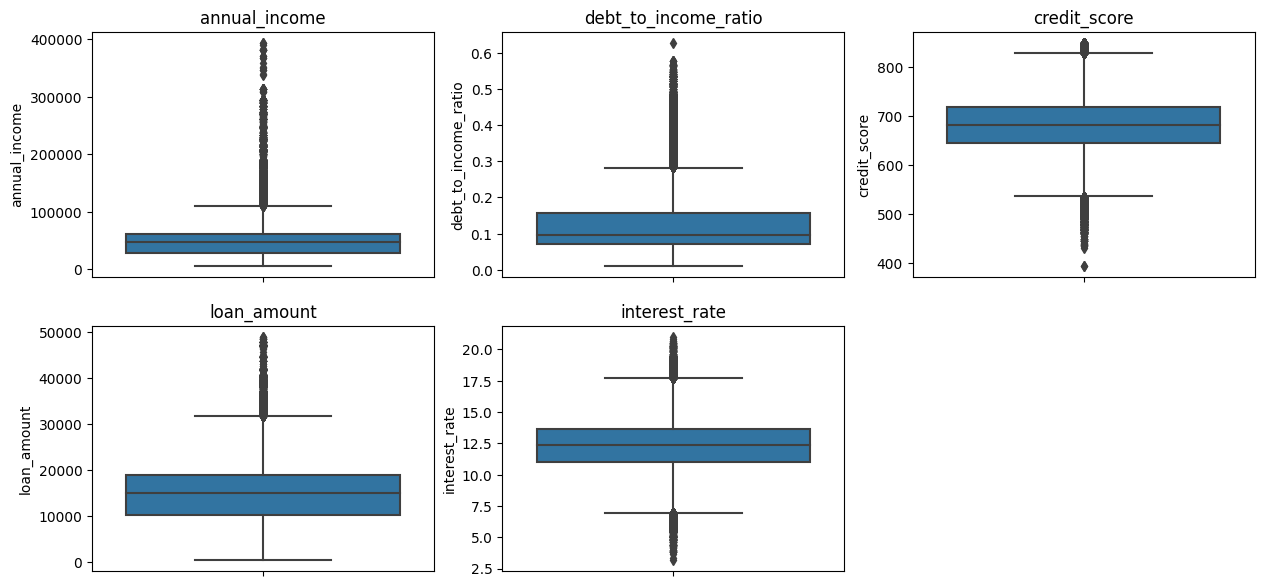

In [94]:
cols = ['annual_income','debt_to_income_ratio','credit_score','loan_amount','interest_rate']

plt.figure(figsize=(15,7))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=dataset[col])
    plt.title(col)

plt.show()

In [95]:

cols = ['annual_income', 'debt_to_income_ratio', 'credit_score',
        'loan_amount', 'interest_rate']

# IQR Method 

for col in cols:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    dataset = dataset[(dataset[col] >= lower) & (dataset[col] <= upper)]


# Z-Mean Score Method
"""
for col in cols:
    min_range = dataset[col].mean() - (3*dataset[col].std())
    max_range = dataset[col].mean() + (3*dataset[col].std())
    x_train = dataset[(dataset[col] >= min_range) & (dataset[col] <= max_range)]
"""

'\nfor col in cols:\n    min_range = dataset[col].mean() - (3*dataset[col].std())\n    max_range = dataset[col].mean() + (3*dataset[col].std())\n    x_train = dataset[(dataset[col] >= min_range) & (dataset[col] <= max_range)]\n'

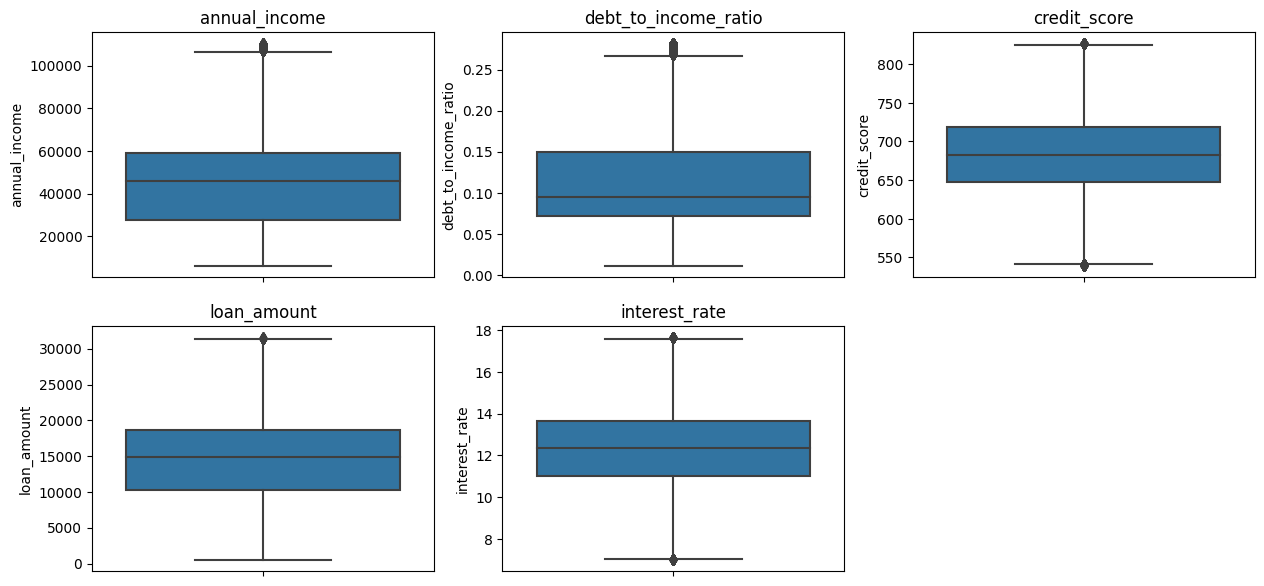

In [96]:
cols = ['annual_income','debt_to_income_ratio','credit_score','loan_amount','interest_rate']

plt.figure(figsize=(15,7))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=dataset[col])
    plt.title(col)

plt.show()

In [97]:
x_train = dataset.iloc[:,:-1]
y_train = dataset['loan_paid_back']

In [98]:
feature_scale = StandardScaler()
dataset = pd.DataFrame(feature_scale.fit_transform(x_train), columns=x_train.columns)

### 5. Feature Selection technique

<Axes: >

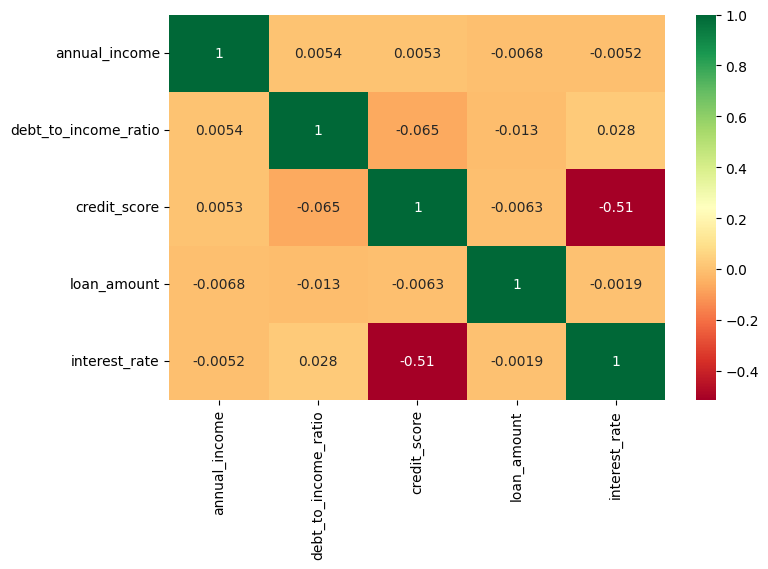

In [99]:
corr_matrix = dataset[['annual_income','debt_to_income_ratio','credit_score','loan_amount','interest_rate']].corr()
top_corr_features = corr_matrix.index

# Plotting the heatmap
plt.figure(figsize=(8,5))
sns.heatmap(data=dataset[top_corr_features].corr(), annot=True, cmap='RdYlGn')


### 6. Classifier Train

#### XGboost Classifier

In [100]:
xgb = XGBClassifier(
    colsample_bytree=0.38427209692144426,
    eval_metric="logloss",
    gamma=0.623699088426236,
    learning_rate=0.0366059523689151,
    max_depth=13,
    min_child_weight=4,
    n_estimators=817,
    objective="binary:logistic",
    reg_alpha=2.2458784299022305,
    reg_lambda=2.9383859608439904,
    subsample=0.9594473169041768,
    random_state=42,
)
xgb.fit(x_train,y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.38427209692144426, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None,
              gamma=0.623699088426236, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.0366059523689151,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=13, max_leaves=None,
              min_child_weight=4, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=817, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

### 7. Final Submission 

In [101]:
def preprocess_data(x_tests):
    # Label Encoding
    label_en = LabelEncoder()
    x_tests[
        ['gender', 'marital_status','education_level', 'employment_status', 'loan_purpose','grade_subgrade']
    ] = label_en.fit_transform(['gender', 'marital_status','education_level', 'employment_status', 'loan_purpose','grade_subgrade'])
    return x_tests

x_test = preprocess_data(x_test)

In [102]:
x_test.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,2,5,0,1,4,3
1,593995,46626.39,0.093,732,15492.25,12.85,2,5,0,1,4,3
2,593996,54954.89,0.367,611,3796.41,13.29,2,5,0,1,4,3
3,593997,25644.63,0.110,671,6574.30,9.57,2,5,0,1,4,3
4,593998,25169.64,0.081,688,17696.89,12.80,2,5,0,1,4,3


In [103]:
sub = pd.read_csv("/kaggle/input/submission/sample_submission.csv")
test_pred = xgb.predict_proba(x_test)[:,1]

sub["loan_paid_back"] = (np.floor(test_pred * 10) / 10)
sub.to_csv("submission.csv", index=False)

print("✅ submission.csv created successfully!")

✅ submission.csv created successfully!


In [104]:
sub

,id,loan_paid_back
0,593994,0.9
1,593995,0.9
2,593996,0.3
3,593997,0.8
4,593998,0.8
...,...,...
254564,848558,0.9
254565,848559,0.7
254566,848560,0.8
254567,848561,0.9
